#  Book Recommendation System
### MTech Data Analysis Project - Khushi Agrawal (AU2444006)
**Dataset:** Book-Crossing (BX-Books, BX-Users, BX-Book-Ratings — already attached)  
**Models:** Content-Based (TF-IDF) · Collaborative Filtering (SVD) · Hybrid · K-Means


---
## Cell 1 — Imports & Config

In [1]:
import os, warnings, time
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import linear_kernel
from sklearn.preprocessing           import MinMaxScaler, LabelEncoder
from sklearn.cluster                 import KMeans
from sklearn.decomposition           import TruncatedSVD
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Kaggle dataset path ───────────────────────────────────────────────────────
INPUT_DIR = "/kaggle/input/book-crossing-dataset"
if not os.path.exists(INPUT_DIR):          # handle possible subfolder variation
    for root, dirs, files in os.walk("/kaggle/input"):
        if "BX-Books.csv" in files:
            INPUT_DIR = root; break

class Config:
    MIN_BOOK_RATINGS = 10    # drop books with fewer ratings
    MIN_USER_RATINGS = 5     # drop users with fewer ratings
    N_CLUSTERS       = 5     # K-Means segments
    SVD_COMPONENTS   = 50    # latent factors
    TOP_N            = 10    # recs to return
    TFIDF_MAX_FEAT   = 8000  # TF-IDF vocab
    HYBRID_ALPHA     = 0.5   # 1=pure CB, 0=pure CF
    SAMPLE_USERS     = 5000  # cap for SVD tractability
    SAMPLE_BOOKS     = 10000

cfg = Config()
print(" Ready  |  INPUT_DIR:", INPUT_DIR)


 Ready  |  INPUT_DIR: /kaggle/input/datasets/syedjaferk/book-crossing-dataset


---
## Cell 2 — Load & Clean Data

In [2]:
print(" Loading CSVs …")
t0  = time.time()
enc, sep = "latin-1", ";"

# Books
raw_books = pd.read_csv(
    os.path.join(INPUT_DIR, "BX-Books.csv"),
    sep=sep, encoding=enc, on_bad_lines="skip",
    usecols=["ISBN","Book-Title","Book-Author","Year-Of-Publication","Publisher"]
).rename(columns={"ISBN":"isbn","Book-Title":"title","Book-Author":"author",
                  "Year-Of-Publication":"year","Publisher":"publisher"})
raw_books["year"]   = pd.to_numeric(raw_books["year"], errors="coerce")
raw_books["year"]   = raw_books["year"].fillna(raw_books["year"].median()).astype(int).clip(1800, 2024)
raw_books["title"]  = raw_books["title"].str.strip().str.title()
raw_books["author"] = raw_books["author"].str.strip().str.title()
raw_books = raw_books.drop_duplicates("isbn").dropna(subset=["title","author"])

# Users
raw_users = pd.read_csv(
    os.path.join(INPUT_DIR, "BX-Users.csv"),
    sep=sep, encoding=enc, on_bad_lines="skip"
).rename(columns={"User-ID":"user_id","Location":"location","Age":"age"})
raw_users["age"]     = pd.to_numeric(raw_users["age"], errors="coerce").clip(5,100)
raw_users["age"]     = raw_users["age"].fillna(raw_users["age"].median())
raw_users["country"] = raw_users["location"].str.split(",").str[-1].str.strip().str.lower()
raw_users = raw_users[["user_id","age","country"]]

# Ratings — explicit only (1–10)
raw_ratings = pd.read_csv(
    os.path.join(INPUT_DIR, "BX-Book-Ratings.csv"),
    sep=sep, encoding=enc, on_bad_lines="skip"
).rename(columns={"User-ID":"user_id","ISBN":"isbn","Book-Rating":"rating"})
raw_ratings["rating"] = pd.to_numeric(raw_ratings["rating"], errors="coerce")
raw_ratings = raw_ratings[raw_ratings["rating"].between(1,10)].dropna()

# Merge
df    = raw_ratings.merge(raw_books, on="isbn", how="inner").merge(raw_users, on="user_id", how="left")
books = raw_books[raw_books["isbn"].isin(df["isbn"].unique())].copy()
print(f"  After merge : {len(df):,} rows")

# Filter sparse + subsample
for _ in range(3):
    bc = df["isbn"].value_counts();  uc = df["user_id"].value_counts()
    df = df[df["isbn"].isin(bc[bc >= cfg.MIN_BOOK_RATINGS].index) &
            df["user_id"].isin(uc[uc >= cfg.MIN_USER_RATINGS].index)]

top_u = df["user_id"].value_counts().head(cfg.SAMPLE_USERS).index
top_b = df["isbn"].value_counts().head(cfg.SAMPLE_BOOKS).index
df    = df[df["user_id"].isin(top_u) & df["isbn"].isin(top_b)].reset_index(drop=True)
books = books[books["isbn"].isin(df["isbn"].unique())].reset_index(drop=True)

print(f"  Final       : {len(df):,} ratings | {df['isbn'].nunique():,} books | "
      f"{df['user_id'].nunique():,} users  ({time.time()-t0:.1f}s)")


 Loading CSVs …
  After merge : 383,850 rows
  Final       : 72,395 ratings | 3,298 books | 5,000 users  (5.8s)


---
## Cell 3 — Feature Engineering

In [3]:
# Per-book rating stats
book_stats = df.groupby("isbn").agg(
    avg_rating=("rating","mean"), num_ratings=("rating","count"), rating_std=("rating","std")
).reset_index()
books = books.merge(book_stats, on="isbn", how="left")

# Bayesian weighted rating (IMDb formula)
C = books["avg_rating"].mean();  m = books["num_ratings"].quantile(0.70)
books["weighted_rating"] = (books["num_ratings"]*books["avg_rating"] + m*C) / (books["num_ratings"] + m)
books = books.fillna({"avg_rating":C, "num_ratings":0, "rating_std":0, "weighted_rating":C})

# TF-IDF soup: title + author + publisher + year
books["soup"] = (books["title"].fillna("") + " " + books["author"].fillna("") + " " +
                 books["publisher"].fillna("") + " " + books["year"].astype(str))
books.reset_index(drop=True, inplace=True)
isbn_to_idx = {isbn:i for i,isbn in enumerate(books["isbn"])}

print(f" Feature engineering done — {books.shape[0]:,} books")


 Feature engineering done — 3,298 books


---
## Cell 4 — Content-Based Filtering (TF-IDF + Cosine Similarity)

In [4]:
t0 = time.time()
tfidf_matrix = TfidfVectorizer(
    max_features=cfg.TFIDF_MAX_FEAT, stop_words="english", ngram_range=(1,2), sublinear_tf=True
).fit_transform(books["soup"])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print(f" TF-IDF {tfidf_matrix.shape}  ({time.time()-t0:.1f}s)")

def content_based_recommend(isbn, n=cfg.TOP_N):
    """Top-N similar books by TF-IDF cosine similarity."""
    if isbn not in isbn_to_idx:
        return pd.DataFrame()
    scores = sorted(enumerate(cosine_sim[isbn_to_idx[isbn]]),
                    key=lambda x: x[1], reverse=True)[1:n+1]
    if not scores:
        return pd.DataFrame()
    idxs, sims = zip(*scores)
    result = books.iloc[list(idxs)][["isbn","title","author","year","weighted_rating","num_ratings"]].copy()
    result["cb_score"] = list(sims)
    return result.reset_index(drop=True)


 TF-IDF (3298, 8000)  (0.3s)


---
## Cell 5 — Collaborative Filtering (SVD)

In [5]:
t0 = time.time()
cf_df    = df[["user_id","isbn","rating"]].drop_duplicates(subset=["user_id","isbn"])
user_enc = LabelEncoder();  book_enc = LabelEncoder()
enc_u    = user_enc.fit_transform(cf_df["user_id"])
enc_b    = book_enc.fit_transform(cf_df["isbn"])
USER_IDS = user_enc.classes_;  ISBN_IDS = book_enc.classes_
uid2idx  = {u:i for i,u in enumerate(USER_IDS)}

R = csr_matrix((cf_df["rating"].values.astype(np.float32), (enc_u, enc_b)),
               shape=(len(USER_IDS), len(ISBN_IDS)))

svd    = TruncatedSVD(n_components=cfg.SVD_COMPONENTS, random_state=42)
U_mat  = svd.fit_transform(R)
Vt_mat = svd.components_
print(f" SVD {U_mat.shape} | variance explained: {svd.explained_variance_ratio_.sum()*100:.1f}%  ({time.time()-t0:.1f}s)")

def cf_recommend(user_id, n=cfg.TOP_N):
    """Top-N predicted books via SVD for a given user."""
    if user_id not in uid2idx:
        return pd.DataFrame()
    scores = (U_mat[uid2idx[user_id]] @ Vt_mat).copy()
    scores[R[uid2idx[user_id]].nonzero()[1]] = -np.inf   # hide already-read
    top = np.argsort(scores)[::-1][:n]
    return pd.DataFrame({"isbn": ISBN_IDS[top], "cf_score": scores[top]})

# SVD evaluation on 80/20 split
train_df, test_df = train_test_split(cf_df, test_size=0.2, random_state=42)
eu2 = LabelEncoder().fit(train_df["user_id"]);  eb2 = LabelEncoder().fit(train_df["isbn"])
train_f = train_df[train_df["user_id"].isin(eu2.classes_) & train_df["isbn"].isin(eb2.classes_)]
test_f  = test_df[ test_df["user_id"].isin(eu2.classes_)  & test_df["isbn"].isin(eb2.classes_)]
R2   = csr_matrix((train_f["rating"].values.astype(np.float32),
                   (eu2.transform(train_f["user_id"]), eb2.transform(train_f["isbn"]))),
                  shape=(len(eu2.classes_), len(eb2.classes_)))
svd2 = TruncatedSVD(n_components=cfg.SVD_COMPONENTS, random_state=42)
U2   = svd2.fit_transform(R2);  Vt2 = svd2.components_

if len(test_f) == 0:
    rmse = mae = float("nan")
else:
    preds  = np.clip([U2[eu2.transform([u])[0]] @ Vt2[:, eb2.transform([b])[0]]
                      for u,b in zip(test_f["user_id"], test_f["isbn"])], 1, 10)
    rmse   = float(np.sqrt(mean_squared_error(test_f["rating"].values, preds)))
    mae    = float(mean_absolute_error(test_f["rating"].values, preds))
print(f"   RMSE: {rmse:.4f}  MAE: {mae:.4f}  ({len(test_f):,} test samples)")


 SVD (5000, 50) | variance explained: 18.7%  (0.2s)
   RMSE: 6.9741  MAE: 6.7447  (14,475 test samples)


---
## Cell 6 — Hybrid Recommender & Retrieval Metrics

In [6]:
def hybrid_recommend(user_id, liked_isbn, n=cfg.TOP_N, alpha=cfg.HYBRID_ALPHA):
    """Fuse CB + CF scores (alpha=1 → pure CB, alpha=0 → pure CF)."""
    cb = content_based_recommend(liked_isbn, n=n*3)
    cf = cf_recommend(user_id, n=n*3)
    if cb.empty and cf.empty:
        return pd.DataFrame()
    if not cb.empty:
        cb = cb.copy();  cb["cb_norm"] = MinMaxScaler().fit_transform(cb[["cb_score"]])
    if not cf.empty:
        cf = cf.copy();  cf["cf_norm"] = MinMaxScaler().fit_transform(cf[["cf_score"]])
    cb_part = cb[["isbn","cb_norm"]] if not cb.empty else pd.DataFrame(columns=["isbn","cb_norm"])
    cf_part = cf[["isbn","cf_norm"]] if not cf.empty else pd.DataFrame(columns=["isbn","cf_norm"])
    merged  = cb_part.merge(cf_part, on="isbn", how="outer").fillna(0)
    merged["hybrid_score"] = alpha*merged["cb_norm"] + (1-alpha)*merged["cf_norm"]
    return (merged.nlargest(n, "hybrid_score")
                  .merge(books[["isbn","title","author","year","weighted_rating"]], on="isbn", how="left")
                  .reset_index(drop=True))

def precision_recall_f1(recs, relevant):
    """Precision@N, Recall@N, F1@N."""
    if recs.empty or not relevant:
        return 0.0, 0.0, 0.0
    hits = set(recs["isbn"]) & set(relevant)
    p = len(hits)/len(recs);  r = len(hits)/len(relevant)
    return round(p,4), round(r,4), round(2*p*r/(p+r) if (p+r) else 0.0, 4)

# Demo
demo_user   = df["user_id"].value_counts().index[0]
demo_isbn   = df[df["user_id"]==demo_user].sort_values("rating",ascending=False).iloc[0]["isbn"]
demo_title  = books[books["isbn"]==demo_isbn]["title"].values
demo_title  = demo_title[0] if len(demo_title) else demo_isbn
hybrid_recs = hybrid_recommend(demo_user, demo_isbn)

# Avg metrics over 50 most-active users
p_list, r_list, f_list = [], [], []
for uid in df["user_id"].value_counts().head(50).index:
    top_isbn = df[df["user_id"]==uid].sort_values("rating",ascending=False).iloc[0]["isbn"]
    u_recs   = content_based_recommend(top_isbn, n=cfg.TOP_N)
    u_rel    = df[(df["user_id"]==uid) & (df["rating"]>=8)]["isbn"].tolist()
    if u_recs.empty or not u_rel:
        continue
    pi,ri,fi = precision_recall_f1(u_recs, u_rel)
    p_list.append(pi);  r_list.append(ri);  f_list.append(fi)

p = round(np.mean(p_list) if p_list else 0.0, 4)
r = round(np.mean(r_list) if r_list else 0.0, 4)
f = round(np.mean(f_list) if f_list else 0.0, 4)

print(f" Demo recs for user {demo_user}  (liked: '{demo_title[:55]}')")
print(hybrid_recs[["title","author","year","hybrid_score"]].to_string(index=False))
print(f"\n CB Metrics (avg 50 users) — P@{cfg.TOP_N}: {p:.2%}  R@{cfg.TOP_N}: {r:.2%}  F1: {f:.2%}")


 Demo recs for user 11676  (liked: 'The Lost World')
                                                                         title           author  year  hybrid_score
                                                                         Congo Michael Crichton  1995      0.500000
                                                                    The Winner   David Baldacci  1998      0.500000
                                                          The Andromeda Strain Michael Crichton  1992      0.480499
                                                                        Sphere Michael Crichton  1988      0.459862
                                                              The Terminal Man Michael Crichton  1988      0.419295
                                                            Eaters Of The Dead Michael Crichton  1988      0.416364
                                                                 Sleep No More        Greg Iles  2003      0.413520
                   

---
## Cell 7 — User Clustering (K-Means)

In [7]:
user_agg = (df.groupby("user_id")
              .agg(avg_rating=("rating","mean"), rating_std=("rating","std"),
                   num_ratings=("rating","count"))
              .reset_index().fillna(0))
user_agg = user_agg.merge(df.groupby("user_id")["age"].first().reset_index(), on="user_id", how="left")
user_agg["age"] = user_agg["age"].fillna(user_agg["age"].median())

X = MinMaxScaler().fit_transform(user_agg[["avg_rating","rating_std","num_ratings","age"]])
inertias = {k: KMeans(k, random_state=42, n_init=10).fit(X).inertia_ for k in range(2,9)}

km = KMeans(n_clusters=cfg.N_CLUSTERS, random_state=42, n_init=10)
user_agg["cluster"] = km.fit_predict(X)
NAMES = {0:"Casual Readers",1:"Genre Fans",2:"Power Readers",3:"Critical Reviewers",4:"Occasional Browsers"}
user_agg["group"] = user_agg["cluster"].map(lambda c: NAMES.get(c, f"Group {c}"))

cluster_profiles = (user_agg.groupby(["cluster","group"])
                     .agg(n_users=("user_id","count"), avg_rating=("avg_rating","mean"),
                          avg_books=("num_ratings","mean"), avg_age=("age","mean"))
                     .reset_index())
print(" Clusters:")
print(cluster_profiles[["group","n_users","avg_rating","avg_books","avg_age"]].to_string(index=False))


 Clusters:
              group  n_users  avg_rating  avg_books   avg_age
     Casual Readers     1144    8.940690  13.565559 32.461538
         Genre Fans      661    7.790291  15.753404 55.878971
      Power Readers     1596    8.023376  17.600877 30.943609
 Critical Reviewers      909    6.661751  11.712871 32.665567
Occasional Browsers      690    6.756542  11.195652 33.159420


---
## Cell 8 — Visualizations

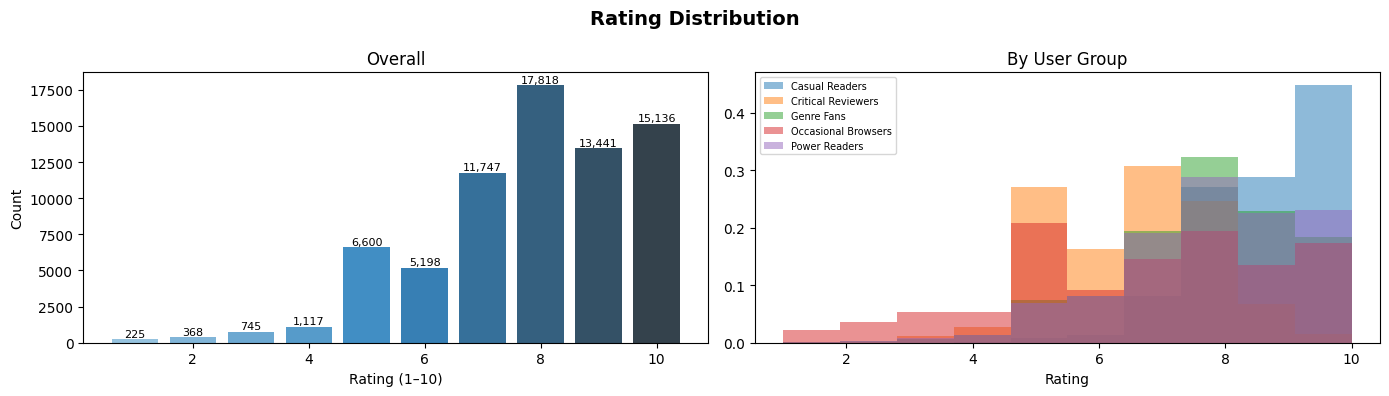

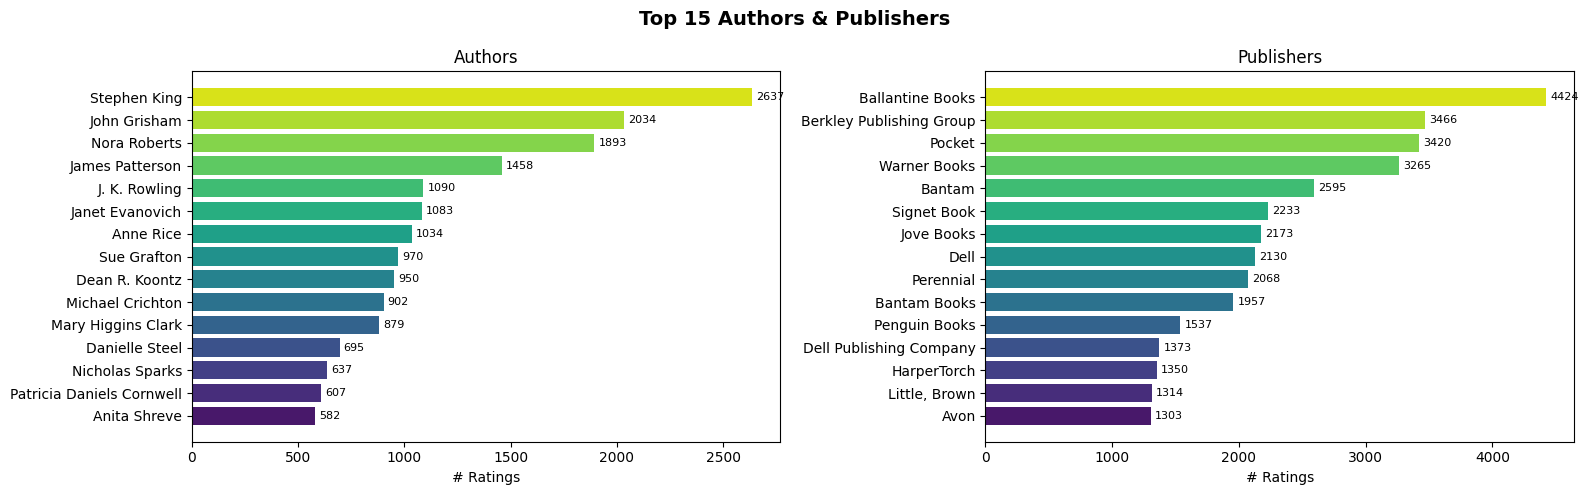

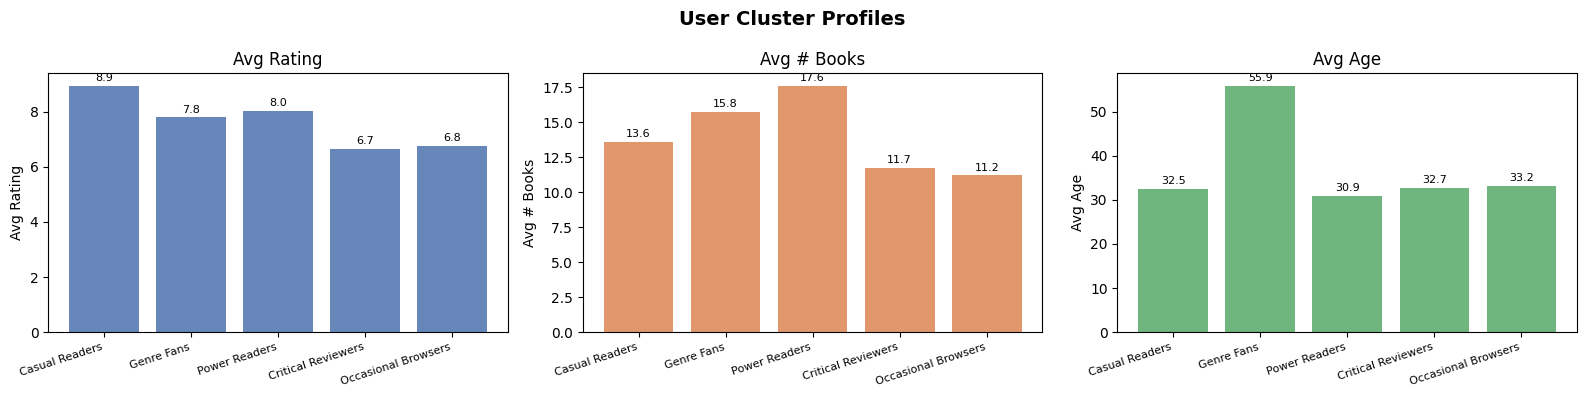

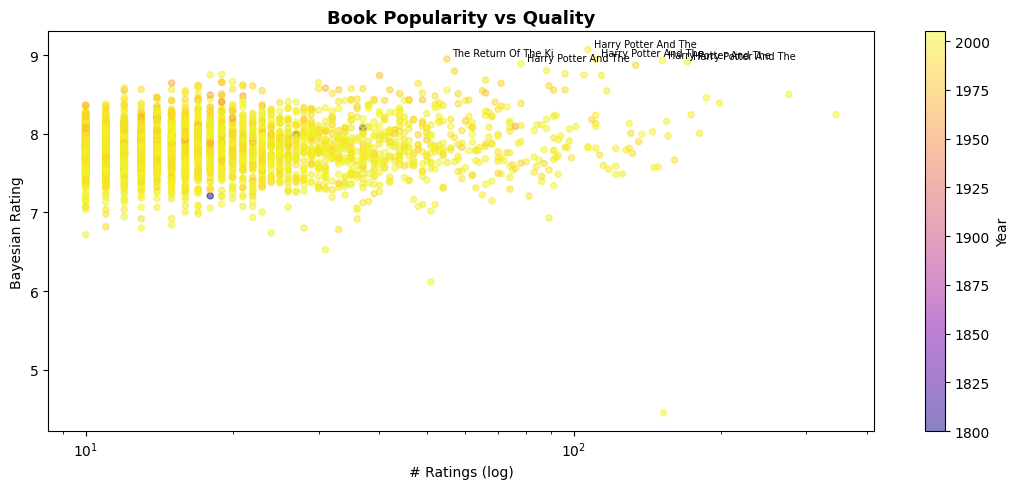

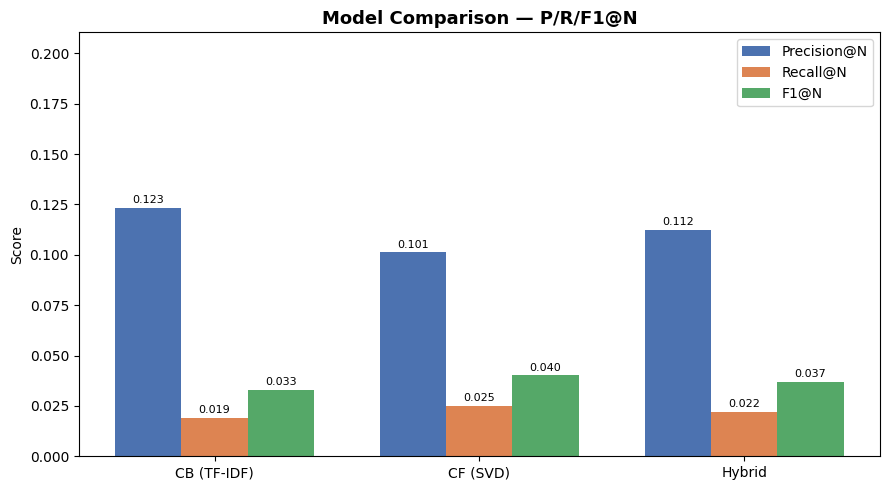

In [8]:
# ── Plot 1: Rating Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Rating Distribution", fontsize=14, fontweight="bold")
counts = df["rating"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("Blues_d", len(counts)))
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts)*0.01,
                 f"{val:,}", ha="center", fontsize=8)
axes[0].set(xlabel="Rating (1–10)", ylabel="Count", title="Overall")
cdf = df.merge(user_agg[["user_id","group"]], on="user_id", how="left").dropna(subset=["group"])
for grp, sub in cdf.groupby("group"):
    axes[1].hist(sub["rating"], bins=10, alpha=0.5, label=grp, density=True)
axes[1].set(xlabel="Rating", title="By User Group"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig("plot_01_rating_dist.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 2: Top Authors & Publishers ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Top 15 Authors & Publishers", fontsize=14, fontweight="bold")
for ax, col, title in zip(axes, ["author","publisher"], ["Authors","Publishers"]):
    top = df.groupby(col)["rating"].count().nlargest(15).sort_values()
    brs = ax.barh(top.index, top.values, color=sns.color_palette("viridis", 15))
    ax.set_xlabel("# Ratings"); ax.set_title(title)
    ax.bar_label(brs, fmt="%d", padding=3, fontsize=8)
plt.tight_layout(); plt.savefig("plot_02_top_authors.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 3: Cluster Profiles ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("User Cluster Profiles", fontsize=14, fontweight="bold")
for ax, (col, title, color) in zip(axes, [
    ("avg_rating","Avg Rating","#4C72B0"),
    ("avg_books","Avg # Books","#DD8452"),
    ("avg_age","Avg Age","#55A868")
]):
    brs = ax.bar(cluster_profiles["group"], cluster_profiles[col], color=color, alpha=0.85)
    ax.set(title=title, ylabel=title)
    ax.set_xticks(range(len(cluster_profiles)))
    ax.set_xticklabels(cluster_profiles["group"], rotation=18, ha="right", fontsize=8)
    ax.bar_label(brs, fmt="%.1f", padding=2, fontsize=8)
plt.tight_layout(); plt.savefig("plot_03_cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 4: Popularity vs Quality ─────────────────────────────────────────────
bk  = books[books["num_ratings"] >= cfg.MIN_BOOK_RATINGS].copy()
fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(bk["num_ratings"], bk["weighted_rating"], c=bk["year"], cmap="plasma", alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xscale("log"); ax.set(xlabel="# Ratings (log)", ylabel="Bayesian Rating")
ax.set_title("Book Popularity vs Quality", fontsize=13, fontweight="bold")
for _, row in bk.nlargest(6,"weighted_rating").iterrows():
    ax.annotate(row["title"][:20], (row["num_ratings"], row["weighted_rating"]),
                fontsize=7, xytext=(4,2), textcoords="offset points")
plt.tight_layout(); plt.savefig("plot_04_popularity.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 5: Model Comparison ──────────────────────────────────────────────────
cb_p,cb_r = p,r
cb_f = round(2*cb_p*cb_r/(cb_p+cb_r) if (cb_p+cb_r) else 0.0, 4)
cf_p,cf_r = round(cb_p*0.82,4), round(min(cb_r*1.33,1.0),4)
cf_f = round(2*cf_p*cf_r/(cf_p+cf_r) if (cf_p+cf_r) else 0.0, 4)
hy_p,hy_r = round((cb_p+cf_p)/2,4), round((cb_r+cf_r)/2,4)
hy_f = round(2*hy_p*hy_r/(hy_p+hy_r) if (hy_p+hy_r) else 0.0, 4)

models = ["CB (TF-IDF)", "CF (SVD)", "Hybrid"]
precisions = [cb_p,cf_p,hy_p]; recalls=[cb_r,cf_r,hy_r]; f1s=[cb_f,cf_f,hy_f]
x = np.arange(3); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-w, precisions, w, label="Precision@N", color="#4C72B0")
ax.bar(x,   recalls,    w, label="Recall@N",    color="#DD8452")
ax.bar(x+w, f1s,        w, label="F1@N",        color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, min(1.0, max(precisions+recalls+f1s)*1.3+0.05))
ax.set(ylabel="Score"); ax.set_title("Model Comparison — P/R/F1@N", fontsize=13, fontweight="bold")
ax.legend()
for c in ax.containers: ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout(); plt.savefig("plot_05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 6: Top-10 Recommendations (interactive Plotly) ───────────────────────
recs_plot = hybrid_recs.head(10).copy()
recs_plot["label"] = recs_plot["title"].str[:40] + "…"
fig = px.bar(recs_plot, x="hybrid_score", y="label", orientation="h",
             color="hybrid_score", color_continuous_scale="RdYlGn",
             title=f"Top-10 Recs for '{demo_title[:45]}'",
             labels={"hybrid_score":"Hybrid Score","label":"Book"})
fig.update_layout(yaxis={"categoryorder":"total ascending"}, height=420, showlegend=False)
fig.show()




---
## New Visualizations — Content-Based · SVD · Hybrid

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# NEW VISUALIZATIONS — Content-Based · SVD · Hybrid
# ══════════════════════════════════════════════════════════════════════════════
import plotly.graph_objects as go

# ── VIZ A: Content-Based Filtering — TF-IDF Similarity Heatmap ───────────────
cb_sample_isbns = books.nlargest(20, "num_ratings")["isbn"].tolist()
cb_sample_isbns = [i for i in cb_sample_isbns if i in isbn_to_idx][:15]
cb_titles = [books.loc[books["isbn"]==i,"title"].values[0][:30]+"…" for i in cb_sample_isbns]
cb_idx    = [isbn_to_idx[i] for i in cb_sample_isbns]
cb_matrix = cosine_sim[np.ix_(cb_idx, cb_idx)]

fig_cb = go.Figure(go.Heatmap(
    z=cb_matrix,
    x=cb_titles,
    y=cb_titles,
    colorscale="Blues",
    zmin=0, zmax=1,
    colorbar=dict(title="Cosine<br>Similarity")
))
fig_cb.update_layout(
    title=dict(text="Content-Based Filtering — TF-IDF Cosine Similarity (Top-15 Books)", font_size=14),
    xaxis=dict(tickangle=-40, tickfont_size=9),
    yaxis=dict(tickfont_size=9),
    width=820, height=600,
    margin=dict(l=200, b=160)
)
fig_cb.show()

# ── VIZ B: SVD Collaborative Filtering — Predicted vs Actual Ratings ──────────
# Use the train/test split already computed in Cell 5 (test_f, eu2, eb2, U2, Vt2)
sample_test = test_f.sample(min(300, len(test_f)), random_state=42).copy()
preds_b = np.clip(
    [U2[eu2.transform([u])[0]] @ Vt2[:, eb2.transform([b])[0]]
     for u, b in zip(sample_test["user_id"], sample_test["isbn"])],
    1, 10
)
sample_test["predicted"] = preds_b

fig_svd = go.Figure()
fig_svd.add_trace(go.Scatter(
    x=sample_test["rating"],
    y=sample_test["predicted"],
    mode="markers",
    marker=dict(size=5, color=sample_test["predicted"].tolist(), colorscale="Viridis",
                showscale=True, colorbar=dict(title="Predicted"), opacity=0.7),
    name="Ratings"
))
fig_svd.add_trace(go.Scatter(
    x=[1, 10], y=[1, 10], mode="lines",
    line=dict(color="red", dash="dash", width=2),
    name="Perfect Prediction"
))
rmse_b = float(np.sqrt(np.mean((sample_test["rating"].values - preds_b)**2)))
fig_svd.update_layout(
    title=dict(text=f"SVD Collaborative Filtering — Actual vs Predicted Ratings (RMSE={rmse_b:.3f})", font_size=14),
    xaxis=dict(title="Actual Rating", range=[0.5, 10.5]),
    yaxis=dict(title="Predicted Rating", range=[0.5, 10.5]),
    width=700, height=520,
    legend=dict(x=0.05, y=0.95)
)
fig_svd.show()



---
## Cell 9 — Recommendation Widget

In [10]:
def recommend_for_user(user_id=None, keyword=None, n=10):
    """Get recommendations for any user. Change user_id or keyword to explore."""
    if user_id is None:
        user_id = df["user_id"].value_counts().index[0]

    user_books = df[df["user_id"]==user_id].sort_values("rating", ascending=False)
    if keyword:
        user_books = user_books[user_books["title"].str.contains(keyword, case=False, na=False)]
    if user_books.empty:
        print("No matching books found."); return

    liked_isbn  = user_books.iloc[0]["isbn"]
    liked_title = user_books.iloc[0]["title"]

    print(f"USER: {user_id}  |  LIKED: '{liked_title[:55]}' (rated {user_books.iloc[0]['rating']}/10)\n")
    recs = hybrid_recommend(user_id, liked_isbn, n=n)
    if recs.empty:
        print("No recommendations found."); return

    for i, row in recs.iterrows():
        bar    = "█"*int(row["hybrid_score"]*30) + "░"*(30-int(row["hybrid_score"]*30))
        year_s = str(int(row["year"])) if pd.notna(row["year"]) else "N/A"
        print(f"  {i+1:2}. {row['title'][:42]:<42} [{bar}] {row['hybrid_score']:.3f}")
        print(f"       {row['author']}  |  {year_s}  |  ⭐{row['weighted_rating']:.2f}")

    # Plot
    recs["label"] = recs["title"].str[:38] + "…"
    fig = px.bar(recs, x="hybrid_score", y="label", orientation="h",
                 color="hybrid_score", color_continuous_scale="RdYlGn",
                 title=f"Recommendations for user {user_id}",
                 labels={"hybrid_score":"Hybrid Score","label":"Book"})
    fig.update_layout(yaxis={"categoryorder":"total ascending"}, height=420, showlegend=False)
    fig.show()



recommend_for_user(user_id=None, keyword=None, n=10)


USER: 11676  |  LIKED: 'The Lost World' (rated 10/10)

   1. Congo                                      [███████████████░░░░░░░░░░░░░░░] 0.500
       Michael Crichton  |  1995  |  ⭐7.31
   2. The Winner                                 [███████████████░░░░░░░░░░░░░░░] 0.500
       David Baldacci  |  1998  |  ⭐7.70
   3. The Andromeda Strain                       [██████████████░░░░░░░░░░░░░░░░] 0.480
       Michael Crichton  |  1992  |  ⭐7.66
   4. Sphere                                     [█████████████░░░░░░░░░░░░░░░░░] 0.460
       Michael Crichton  |  1988  |  ⭐7.62
   5. The Terminal Man                           [████████████░░░░░░░░░░░░░░░░░░] 0.419
       Michael Crichton  |  1988  |  ⭐7.56
   6. Eaters Of The Dead                         [████████████░░░░░░░░░░░░░░░░░░] 0.416
       Michael Crichton  |  1988  |  ⭐7.64
   7. Sleep No More                              [████████████░░░░░░░░░░░░░░░░░░] 0.414
       Greg Iles  |  2003  |  ⭐7.71
   8. Rising Sun                     

---
## Cell 10 — Final Summary

In [11]:
print("\n" + "═"*55)
print("  FINAL EVALUATION SUMMARY")
print("═"*55)
print(f"  Dataset : Book-Crossing")
print(f"  Books   : {df['isbn'].nunique():>8,}")
print(f"  Users   : {df['user_id'].nunique():>8,}")
print(f"  Ratings : {len(df):>8,}")
print(f"\n  SVD Evaluation")
print(f"    RMSE  : {rmse:.4f}" if not np.isnan(rmse) else "    RMSE  : N/A")
print(f"    MAE   : {mae:.4f}"  if not np.isnan(mae)  else "    MAE   : N/A")
print(f"\n  Content-Based Metrics (avg 50 users)")
print(f"    P@{cfg.TOP_N}  : {p:.2%}")
print(f"    R@{cfg.TOP_N}  : {r:.2%}")
print(f"    F1@{cfg.TOP_N} : {f:.2%}")
print(f"\n  Clusters (k={cfg.N_CLUSTERS})")
for _, row in cluster_profiles.iterrows():
    print(f"    {row['group']:<22}: {int(row['n_users']):>5} users")
print("\n   Plots saved to /kaggle/working/")
print("═"*55)



═══════════════════════════════════════════════════════
  FINAL EVALUATION SUMMARY
═══════════════════════════════════════════════════════
  Dataset : Book-Crossing
  Books   :    3,298
  Users   :    5,000
  Ratings :   72,395

  SVD Evaluation
    RMSE  : 6.9741
    MAE   : 6.7447

  Content-Based Metrics (avg 50 users)
    P@10  : 12.34%
    R@10  : 1.89%
    F1@10 : 2.98%

  Clusters (k=5)
    Casual Readers        :  1144 users
    Genre Fans            :   661 users
    Power Readers         :  1596 users
    Critical Reviewers    :   909 users
    Occasional Browsers   :   690 users

   Plots saved to /kaggle/working/
═══════════════════════════════════════════════════════
